## Regressão Linear Múltipla

Dado um conjunto de observações

$$
V = \{(x_{i1}, x_{i2}, \dots, x_{ip}, y_i)\}_{i=1}^n
$$
    
queremos determinar o vetor de parâmetros $\beta$ tal que

$$
Y = X\beta + \varepsilon
$$

onde $X$, $Y$ e $\beta$ são dados por:
    
$$
  X =
  \begin{bmatrix}
  1 & x_{11} & x_{12} & \cdots & x_{1p} \\
  1 & x_{21} & x_{22} & \cdots & x_{2p} \\
  \vdots & \vdots & \vdots & \ddots & \vdots \\
  1 & x_{n1} & x_{n2} & \cdots & x_{np}
  \end{bmatrix},
  \qquad
  Y =
  \begin{bmatrix}
  y_1 \\ y_2 \\ \vdots \\ y_n
  \end{bmatrix},
  \qquad
  \beta =
  \begin{bmatrix}
  \beta_0 \\ \beta_1 \\ \vdots \\ \beta_p
  \end{bmatrix}.
$$

Seja

$$
\mathcal{L}(\beta) := \sum_{i=1}^{n} (y_i - x_i^{\top}\beta)^{2},
$$

a soma dos erros quadrados. Podemos reescrever:

\begin{align*}
    \mathcal{L}(\beta)
    &= \lVert Y - X\beta \rVert^{2} \\
    &= (Y - X\beta)^{\top}(Y - X\beta) \\
    &= Y^{\top}Y -Y^{\top}X\beta -(X\beta)^{\top}Y + (X\beta)^{\top}X\beta\\
    &= Y^{\top}Y - 2Y^{\top}X\beta + \beta^{\top}X^{\top}X\beta.
\end{align*}

Vamos derivar $\mathcal{L}$ com relação a $\beta$ e igualar a zero:

\begin{align*}
    \frac{d\mathcal{L}}{d\beta}
    &= \frac{d}{d\beta}\left(
        Y^{\top}Y
        - 2Y^{\top}X\beta
        + \beta^{\top}X^{\top}X\beta
    \right) \\
    &= 0 - 2X^{\top}Y + 2X^{\top}X\beta.
\end{align*}

Fazendo $\dfrac{d\mathcal{L}}{d\beta} = 0$, temos que:

\begin{align*}
    \dfrac{d\mathcal{L}}{d\beta} &= 0 \\
    -2X^{\top}Y + 2X^{\top}X\hat{\beta} &= 0 \\
    X^{\top}X\hat{\beta} &= X^{\top}Y \\
    \hat{\beta} &= (X^{\top}X)^{-1}X^{\top}Y.
\end{align*}

Assim, encontramos $\hat{\beta}$ que minimiza a soma dos erros quadrados.

## Aplicação Básica da Regressão Linear Múltipla

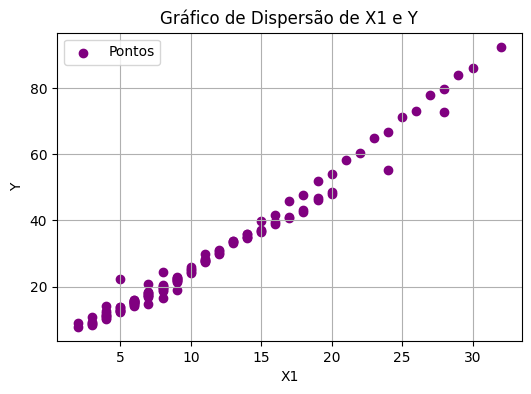

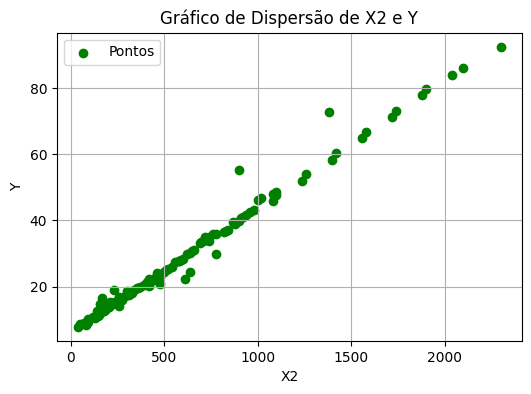

In [2]:
import numpy as np
import matplotlib.pyplot as plt

X = np.loadtxt("data.csv", delimiter=",")

X1 = X[:,0]
X2 = X[:, 1]
Y = X[:, 2]

plt.figure(figsize=(6,4))
plt.scatter(X1, Y, color='purple', label='Pontos')
plt.xlabel("X1")
plt.ylabel("Y")
plt.title("Gráfico de Dispersão de X1 e Y")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(X2, Y, color='green', label='Pontos')
plt.xlabel("X2")
plt.ylabel("Y")
plt.title("Gráfico de Dispersão de X2 e Y")
plt.grid(True)
plt.legend()
plt.show()

### Visualização do Gráfico de Dispersão entre $X_1$, $X_2$ e $Y$:

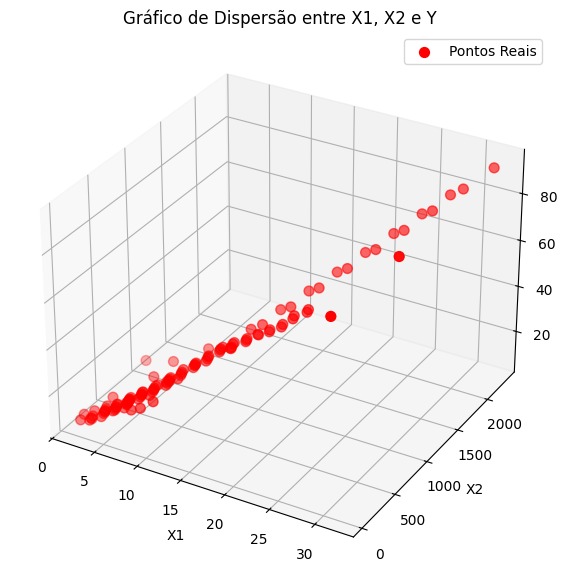

In [3]:
fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color="red", s=50, label='Pontos Reais')
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
plt.title("Gráfico de Dispersão entre X1, X2 e Y")
plt.legend()
plt.show()


### Visualização de um plano genérico $y = a + bx_1 + cx_2$ e marcação dos resíduos:

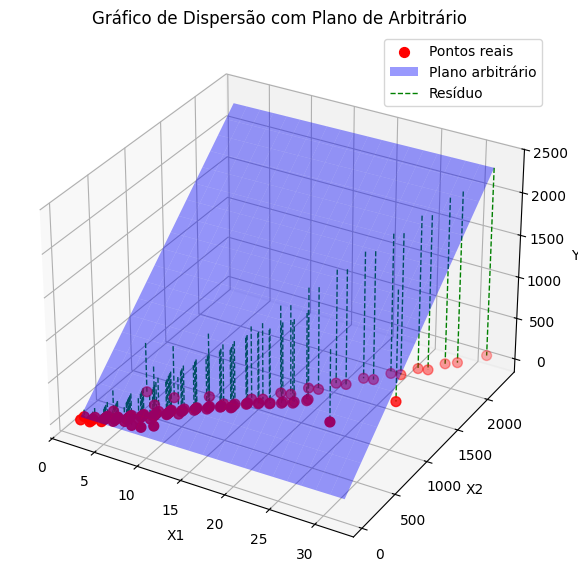

In [4]:
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(X1), max(X1), 20),
    np.linspace(min(X2), max(X2), 20)
)

a, b, c = 1, 1, 1
y_plane = a + b*x1_grid + c*x2_grid

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color="red", s=50, label="Pontos reais")

ax.plot_surface(x1_grid, x2_grid, y_plane, alpha=0.4, color='blue', label='Plano arbitrário')

ax.plot([], [], [], color='green', linestyle='--', linewidth=1, label='Resíduo')

for x1i, x2i, yi in zip(X1, X2, Y):
    ypi = a + b*x1i + c*x2i
    residuo = yi - ypi

    ax.plot([x1i, x1i], [x2i, x2i], [ypi, yi], color='green', linestyle='--', linewidth=1)

ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
plt.title("Gráfico de Dispersão com Plano de Arbitrário")
plt.legend()
plt.show()



### Cálculo da Regressão Linear Múltipla e Plano $y = \beta_0 + \beta_1x_1 + \beta_2x_2$ após minimização:



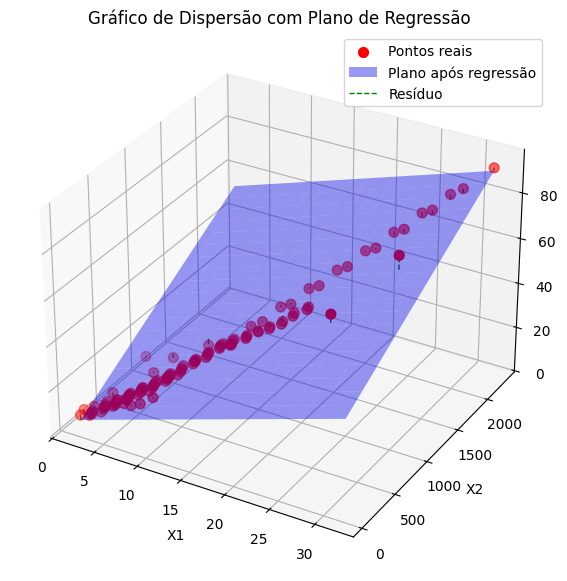

In [6]:
x1_grid, x2_grid = np.meshgrid(
    np.linspace(min(X1), max(X1), 20),
    np.linspace(min(X2), max(X2), 20)
)

X = np.column_stack((np.ones(len(X1)), X1, X2))
beta = np.linalg.inv(X.T @ X) @ (X.T @ Y)
b0, b1, b2 = beta

y_plane = b0 + b1*x1_grid + b2*x2_grid

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, Y, color="red", s=50, label="Pontos reais")

ax.plot_surface(x1_grid, x2_grid, y_plane, alpha=0.4, color='blue', label='Plano após regressão')

ax.plot([], [], [], color='green', linestyle='--', linewidth=1, label='Resíduo')

for x1i, x2i, yi in zip(X1, X2, Y):
    ypi = b0 + b1*x1i + b2*x2i
    residuo = yi - ypi

    ax.plot([x1i, x1i], [x2i, x2i], [ypi, yi], color='green', linestyle='--', linewidth=1)


ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_zlabel("Y")
plt.title("Gráfico de Dispersão com Plano de Regressão")
plt.legend()
plt.show()
